# Lab 9 Report: 
## Final Project Codebase

## Project Title: Facial Recognition

### Group Members: Javier Guapilla Diaz & McKinley Nhi Seecof Quevedo

--------------------

## Imports

In [134]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import os
from PIL import Image # For easy manipulation of images and stuff
d = torch.device('cuda')

## Prepare Data

Loading In Data

In [150]:
folders = ["train", "test"]
emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
# NOTE: This is for my PC (Javier)
path = r"C:\Users\jguap\OneDrive\Desktop\spr26\final_data\data\\"

IMG_SIZE = (48, 48)

# training data
train_data = []
train_labels = []

# testing data
test_data = []
test_labels = []

# loading data
for f in folders:
    for i in range(len(emotions)):
        e = emotions[i]
        curr_path = os.path.join(path, f, e)
        for filename in os.listdir(curr_path):
            # getting the images
            curr_image_path = os.path.join(curr_path, filename)
            curr_image = Image.open(curr_image_path).convert("L")
            curr_image = curr_image.resize(IMG_SIZE)

            # putting them where they go
            if f == "train":
                train_data.append(np.array(curr_image))
                train_labels.append(i)
                # add rotations
                # train_data.append(np.array(curr_image.rotate(90)))
                # train_labels.append(i)
                # train_data.append(np.array(curr_image.rotate(180)))
                # train_labels.append(i)
                # train_data.append(np.array(curr_image.rotate(270)))
                # train_labels.append(i)
                train_data.append(np.array(curr_image.transpose(Image.FLIP_LEFT_RIGHT)))
                train_labels.append(i)

            if f == "test":
                test_data.append(np.array(curr_image))
                test_labels.append(i)

# converting to np arrays
train_data = np.array(train_data)
test_data = np.array(test_data)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

train_data = train_data.reshape(-1, 1, 48, 48)
test_data = test_data.reshape(-1, 1, 48, 48)


In [151]:
print(train_data.shape)
print(test_data.shape)

(57418, 1, 48, 48)
(7178, 1, 48, 48)


Reshaping

In [152]:
train_data = np.reshape(train_data, (57418, (48*48)))# YOUR CODE HERE
test_data = np.reshape(test_data, (7178, (48*48)))# YOUR CODE HERE

ValidationTraining $\rightarrow$ Training (90\%) & Validation (10\%)

In [153]:
# Take the first 1000 training features and targets as validation set
from sklearn.model_selection import train_test_split #importing a data splitter

spl = train_test_split(train_data, 
                       train_labels, 
                       test_size=0.1,random_state=2)
# ^^ Splits data in following order: train feature, validation features, train targets, validation targets

validation_data = spl[1]
validation_labels = spl[3]

# Take the remaining 9000 training features and targets as training set 
train_data = spl[0]
train_labels = spl[2]

# Checking sizes to make sure I split correctly
print(validation_data.shape, validation_labels.shape)
print(train_data.shape, train_labels.shape)

(5742, 2304) (5742,)
(51676, 2304) (51676,)


Scaling

In [154]:
# Defining scaling function
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale the dataset according to standard scaling
train_data = scaler.fit_transform(train_data) # Fitting to and scaling training data 
validation_data = scaler.transform(validation_data)
test_data = scaler.transform(test_data)# scaling testing data

In [155]:
# Reshape train/validation/test sets to conform to PyTorch's (N, Channels, Height, Width) standard for CNNs

train_features = train_data.reshape(-1, 1, 48, 48) # Going back to 48X48 images for CNN
validation_features = validation_data.reshape(-1, 1, 48, 48) # ^^
test_features = test_data.reshape(-1,1,48,48) # ^^

# Checking the shape
print(train_features.shape)
print(validation_features.shape)
print(test_features.shape)

(51676, 1, 48, 48)
(5742, 1, 48, 48)
(7178, 1, 48, 48)


Converting to Tensors

In [156]:
# Make them into tensors
train_inputs = torch.from_numpy(train_features).float() # converting to floats
train_targets = torch.from_numpy(train_labels).long() # converting to 64-bit integer

validation_inputs = torch.from_numpy(validation_features).float().to(d) # converting to floats
validation_targets = torch.from_numpy(validation_labels).long().to(d) # converting to 64-bit integer

testing_inputs = torch.from_numpy(test_features).float().to(d) # converting to floats
testing_targets = torch.from_numpy(test_labels).long().to(d) # converting to 64-bit integer

# NOTE: Each of the tensors above used .to(d) which takes out tensors and puts them "in" my computers gpu
#       I did this to speed up computation and to actually use cuda.

## Define Model

In [190]:
# Define your CNN architecture here
import torch.nn.functional as F

class myCNNModel(torch.nn.Module):
    
    def __init__(self):
        
        super(myCNNModel, self).__init__()
        
        # Convolution followed by ReLU activation and a Maxpool
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=32,
                              kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution followed by ReLU activation and a Maxpool
        self.cnn2 = nn.Conv2d(in_channels=32, out_channels=64, 
                              kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # added
        self.cnn3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        self.bn3 = nn.BatchNorm2d(128)

        # Squishing down to fully connected chunk.
        # self.fc1 = nn.Linear(128*6*6, 256)
        # self.fc2 = nn.Linear(256, 7)
        self.fc1 = nn.Linear(128*6*6, 64)
        self.fc2 = nn.Linear(64, 7)

        # Batch normalizations used:
        self.bn = nn.BatchNorm1d(64)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)

        # dropouts
        self.dropout = nn.Dropout(0.5)
        self.dropout_conv = nn.Dropout(0.25)
    
    def forward(self, x):
        
        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.dropout_conv(out) # *

        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.dropout_conv(out) # * 

        # ^ same as before
        out = self.cnn3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = self.dropout_conv(out) # *Googled how to reduce overfitting and added this dropout

        # Flattening out our output
        out = out.view(out.size(0), -1)

        # Using a fully connected layer for the rest
        out = self.fc1(out)
        out = self.bn(out)
        out = F.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

## Define Hyperparameters

In [196]:
# Fix the random seed so that model performance is reproducible
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader #added dataloader so that random data is batched
torch.manual_seed(55)

# Initializing model
model = myCNNModel()
model = model.to(d) # Bc I wanted to use my gpu, also "sent" model to GPU to work w/ tensors from before.

# Defining learning rate, epoch and batchsize for mini-batch gradient
learning_rate = 0.001
epochs = 20 #20 #30

## Mini-batch set up, splitting up the tensors from before
batchsize = 64
# train_batches_features = torch.split(train_inputs, batchsize)
# train_batches_targets = torch.split(train_targets, batchsize)
# batch_split_num = len(train_batches_features)
train_dataset = TensorDataset(train_inputs, train_targets)
# NOTE: num_workers is for threads, and pin_memory is for locking memory
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, pin_memory=True, num_workers=2)

# Define loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-6)

model # just to check the model I am using

myCNNModel(
  (cnn1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4608, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

## Identify Tracked Values

In [197]:
# Placeholders for training loss and validation accuracy during training
train_loss_list = []
validation_loss_list = []
validation_accuracy_list = []

## Train Model

In [198]:
import tqdm #For loading bar

# Actual training of the modeL:
for epoch in tqdm.trange(epochs):
    
    model.train() # I was told in a previous class doing this is good practice.
    e_loss = 0.0 # the average loss for this epoch bc I use mini-batch
    
    # Working w the batches
    # for k in range(batch_split_num):
    for features, targets in train_loader:
        # set up:
        # using batch k to train on
        # features_k = train_batches_features[k]
        # targets_k = train_batches_targets[k]
        features_k = features.to(d)
        targets_k = targets.to(d)

        # training
        optimizer.zero_grad()
        train_batch_outputs = model(features_k)
        loss = loss_func(train_batch_outputs, targets_k)
        e_loss += loss.item()

        # moving the optimizer along
        loss.backward()
        optimizer.step()
    
    # getting the avg loss over the batches for this epoch
    # epoch_avg_loss = e_loss / batch_split_num
    epoch_avg_loss = e_loss / len(train_loader)
    train_loss_list.append(epoch_avg_loss)

    # Compute Validation Accuracy ----------------------------------------------------------------------
    model.eval() # Once again, I was told putting the model explicitly into eval mode was good practice
    with torch.no_grad(): # Telling PyTorch we aren't passing inputs to network for training purpose
        
        validation_outputs = model(validation_inputs) # Getting validation scores
        val_loss = loss_func(validation_outputs, validation_targets)
        validation_loss_list.append(val_loss.item())

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor) # converting validation scores to labels and
                                                               # counting the # of correctly labeled samples
        
        validation_accuracy_list.append(correct.mean()) # converting # of samples correct to percentage
        # scheduler.step(val_loss.item())


100%|██████████| 20/20 [04:53<00:00, 14.67s/it]


## Visualize & Evaluate Model

Validation

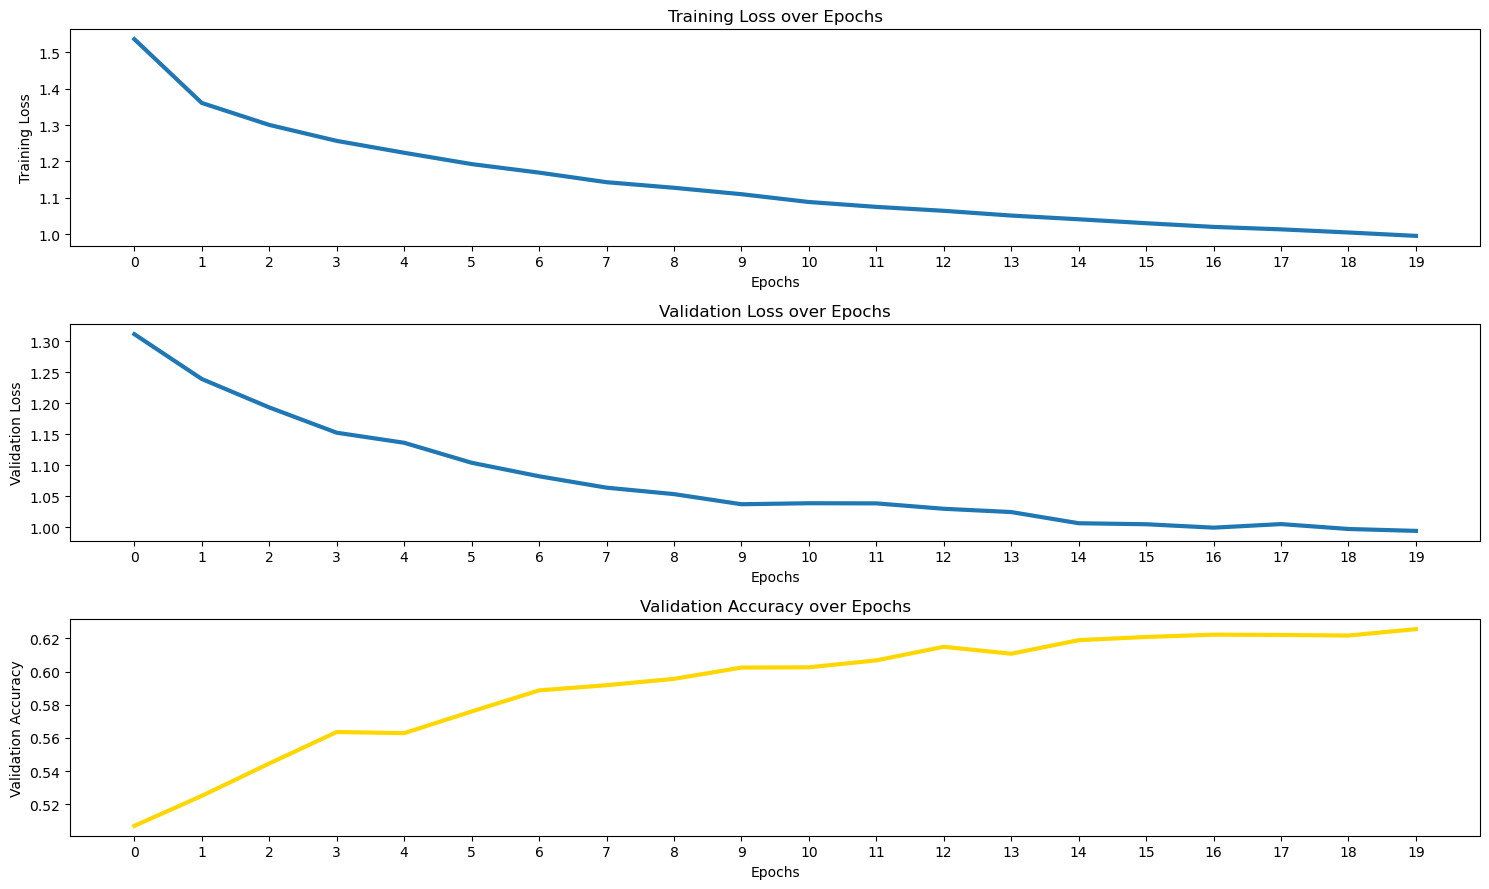

In [199]:
# Visualizing training loss and validation set accuracy
plt.figure(figsize = (15, 9))
xt = np.arange(20)

# Plot for Training Loss
plt.subplot(3, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.title("Training Loss over Epochs")
plt.ylabel("Training Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

plt.subplot(3, 1, 2)
plt.plot(validation_loss_list, linewidth = 3)
plt.title("Validation Loss over Epochs")
plt.ylabel("Validation Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

# Accuracy for validation set
plt.subplot(3, 1, 3)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.title("Validation Accuracy over Epochs")
plt.ylabel("Validation Accuracy")
plt.xlabel("Epochs")
plt.xticks(xt)
plt.tight_layout() #googled for overlapping labels
plt.show()

Test

In [200]:
# Compute the testing accuracy
model.eval() # good practice again
with torch.no_grad():
    # testing model on test samples to get predicted values
    y_pred_test = model(testing_inputs) 
    
    # Use the same technique as above to compute the testing classification accuracy
    predicted_targets = torch.argmax(y_pred_test, dim=1)
    correct = (predicted_targets == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()*100) + '%') # printing the percentage

Testing Accuracy: 61.14517%


In [177]:
tt = testing_targets.cpu().numpy() #these are my true labels
pt = predicted_targets.cpu().numpy() # these are the predicted labels

# List of the different items we classified
c = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

print("--- Accuracy By Class ---\n")

# Looping over different classes/targets
for i in range(7):
    # Finding the accuracy:
    idx_k = np.where(tt==i) # finding true labels' indexs
    predicted_k = pt[idx_k] # using idx_k to find the predicted labels
    true_k = tt[idx_k] # getting the true labels
    percent_k = np.mean(predicted_k == true_k) # comparing true vs predicted

    # printing and formatting
    print("Accuracy of", c[i]+":", f"{percent_k*100:.2f}%")
    # ^ I used an f-string cuz it made formatting the percentage nicer

--- Accuracy By Class ---

Accuracy of angry: 55.64%
Accuracy of disgust: 54.95%
Accuracy of fear: 40.72%
Accuracy of happy: 84.89%
Accuracy of neutral: 57.18%
Accuracy of sad: 55.09%
Accuracy of surprise: 83.75%
